# Notebook 03 — Análise Exploratória e Preparação para PyTorch

**Etapa 3 — Semana 3**

Partindo da `amostra_rotulada.csv` (Etapa 2), este notebook:
1. Analisa a distribuição das classes e o comprimento dos textos (EDA)
2. Tokeniza os textos para NLP
3. Constrói o vocabulário e codifica os textos
4. Codifica os rótulos
5. Cria e testa o Dataset PyTorch
6. Compara com a biblioteca PyTorch-NLP

---

In [16]:
import sys
sys.path.append('..')

import re
import json
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import DataLoader

from src.dataset import tokenizar, codificar_texto, DiarioDataset, MAX_LEN

df = pd.read_csv('../data/processed/amostra_rotulada.csv')
print(f'Base carregada: {df.shape[0]} registros, {df["rotulo"].nunique()} classes')
df.head(3)

Base carregada: 42 registros, 6 classes


,id,data_publicacao,numero_edicao,tipo_ato,titulo,secretaria,texto,url_original,rotulo
0,DOA-2026-001,2026-05-14,2732,Decretos,Decreto 8742 – Crédito Adicional Suplementar,Secretaria de Finanças,"DECRETO Nº 8.742, DE 14 DE MAIO DE 2026.\nAbre...",https://www.dosp.com.br/exibe_do.php?i=ODE3ODM2,decreto
1,DOA-2026-002,2026-05-04,2724,Decretos,Decreto 1109 – Regulamenta Serviço de Transporte,Secretaria de Transporte,"DECRETO Nº 1.109, DE 04 DE MAIO DE 2026.\nRegu...",https://www.dosp.com.br/exibe_do.php?i=ODEyNzQ5,decreto
2,DOA-2026-003,2026-01-30,2649,Decretos,Decreto 990 – Estabelece Ponto Facultativo,Secretaria de Administração,"DECRETO Nº 990, DE 30 DE JANEIRO DE 2026.\nEst...",https://www.dosp.com.br/exibe_do.php?i=NzcwODAx,decreto


---
## Atividade 1 — Análise Exploratória (EDA)

### 1.1 Distribuição das classes

In [17]:
contagem = df['rotulo'].value_counts()
print(contagem)
print(f'\nClasse majoritária: {contagem.index[0]} ({contagem.iloc[0]} registros)')
print(f'Classe minoritária: {contagem.index[-1]} ({contagem.iloc[-1]} registros)')
print(f'Razão max/min: {contagem.iloc[0]/contagem.iloc[-1]:.1f}x')

rotulo
decreto               12
licitacao_contrato     8
portaria               7
ato_pessoal            5
edital_concurso        5
contas_publicas        5
Name: count, dtype: int64

Classe majoritária: decreto (12 registros)
Classe minoritária: contas_publicas (5 registros)
Razão max/min: 2.4x


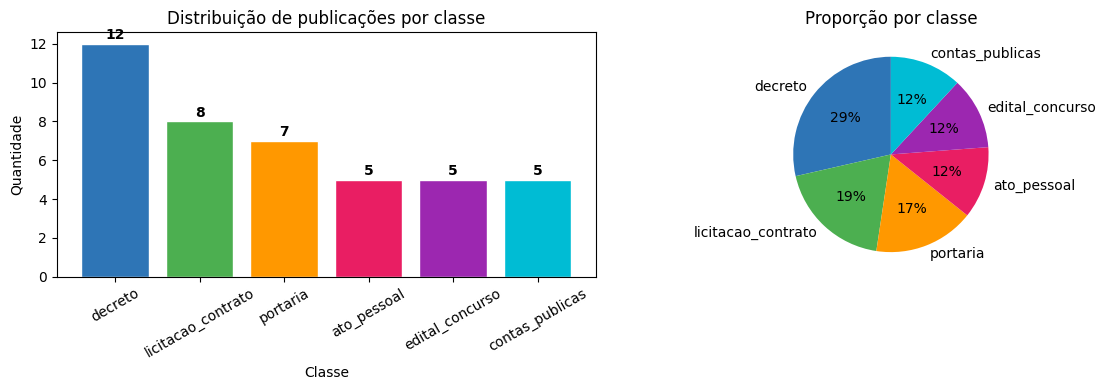

Gráfico salvo em docs/distribuicao_classes.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barras
cores = ['#2E75B6','#4CAF50','#FF9800','#E91E63','#9C27B0','#00BCD4']
bars = axes[0].bar(contagem.index, contagem.values, color=cores, edgecolor='white')
axes[0].set_title('Distribuição de publicações por classe', fontsize=12)
axes[0].set_xlabel('Classe'); axes[0].set_ylabel('Quantidade')
axes[0].tick_params(axis='x', rotation=30)
for bar, v in zip(bars, contagem.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 str(v), ha='center', va='bottom', fontweight='bold')

# Pizza
axes[1].pie(contagem.values, labels=contagem.index, autopct='%1.0f%%',
            colors=cores, startangle=90)
axes[1].set_title('Proporção por classe', fontsize=12)

plt.tight_layout()
plt.savefig('../docs/distribuicao_classes.png', dpi=150)
plt.show()
print('Gráfico salvo em docs/distribuicao_classes.png')

**Interpretação:** A classe `decreto` tem mais exemplos (12) enquanto `ato_pessoal`, `edital_concurso` e `contas_publicas` têm apenas 5. O desbalanceamento (razão 2,4x) é moderado para o tamanho da base — na Etapa 4, podemos usar class weights para compensar.

### 1.2 Comprimento dos textos

In [19]:
df['n_tokens'] = df['texto'].apply(lambda t: len(tokenizar(t)))

print('Estatísticas de comprimento (tokens após stopwords):')
print(df['n_tokens'].describe().round(1))
print(f'\nPercentil 90: {df["n_tokens"].quantile(0.90):.0f}')
print(f'Percentil 95: {df["n_tokens"].quantile(0.95):.0f}')
print(f'\nMAX_LEN adotado: {MAX_LEN}')

Estatísticas de comprimento (tokens após stopwords):
count    42.0
mean     40.6
std       6.6
min      31.0
25%      34.2
50%      40.0
75%      45.8
max      57.0
Name: n_tokens, dtype: float64

Percentil 90: 48
Percentil 95: 51

MAX_LEN adotado: 60


C:\Users\John\AppData\Local\Temp\ipykernel_12028\1062306652.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_box, labels=classes_ord, patch_artist=True)


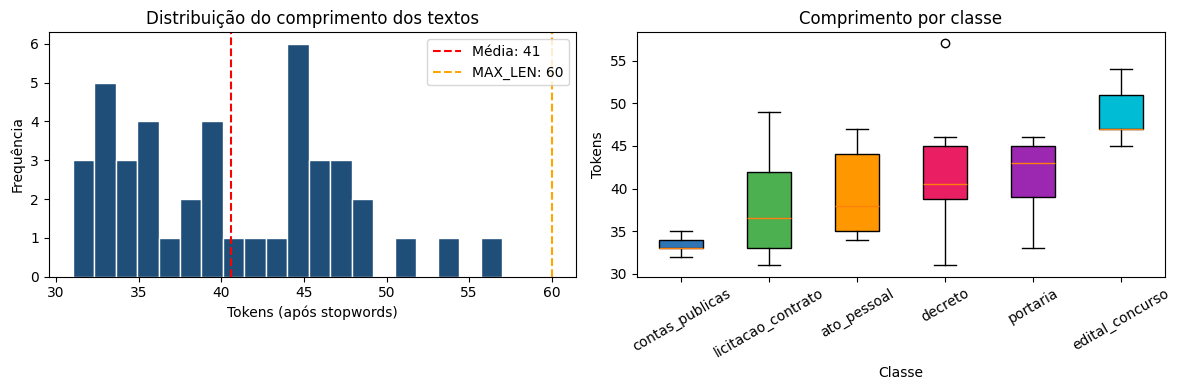

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma geral
axes[0].hist(df['n_tokens'], bins=20, color='#1F4E79', edgecolor='white')
axes[0].axvline(df['n_tokens'].mean(), color='red', linestyle='--',
                label=f'Média: {df["n_tokens"].mean():.0f}')
axes[0].axvline(MAX_LEN, color='orange', linestyle='--',
                label=f'MAX_LEN: {MAX_LEN}')
axes[0].set_title('Distribuição do comprimento dos textos', fontsize=12)
axes[0].set_xlabel('Tokens (após stopwords)'); axes[0].set_ylabel('Frequência')
axes[0].legend()

# Boxplot por classe
classes_ord = df.groupby('rotulo')['n_tokens'].median().sort_values().index
data_box = [df[df['rotulo']==c]['n_tokens'].values for c in classes_ord]
bp = axes[1].boxplot(data_box, labels=classes_ord, patch_artist=True)
for patch, cor in zip(bp['boxes'], cores):
    patch.set_facecolor(cor)
axes[1].set_title('Comprimento por classe', fontsize=12)
axes[1].set_xlabel('Classe'); axes[1].set_ylabel('Tokens')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../docs/comprimento_textos.png', dpi=150)
plt.show()

**Interpretação:** A média é ~40 tokens e o percentil 95 é 50. Adotamos `MAX_LEN = 60` para cobrir virtualmente todos os textos com margem de segurança, sem desperdiçar memória.

### 1.3 Termos mais frequentes por classe

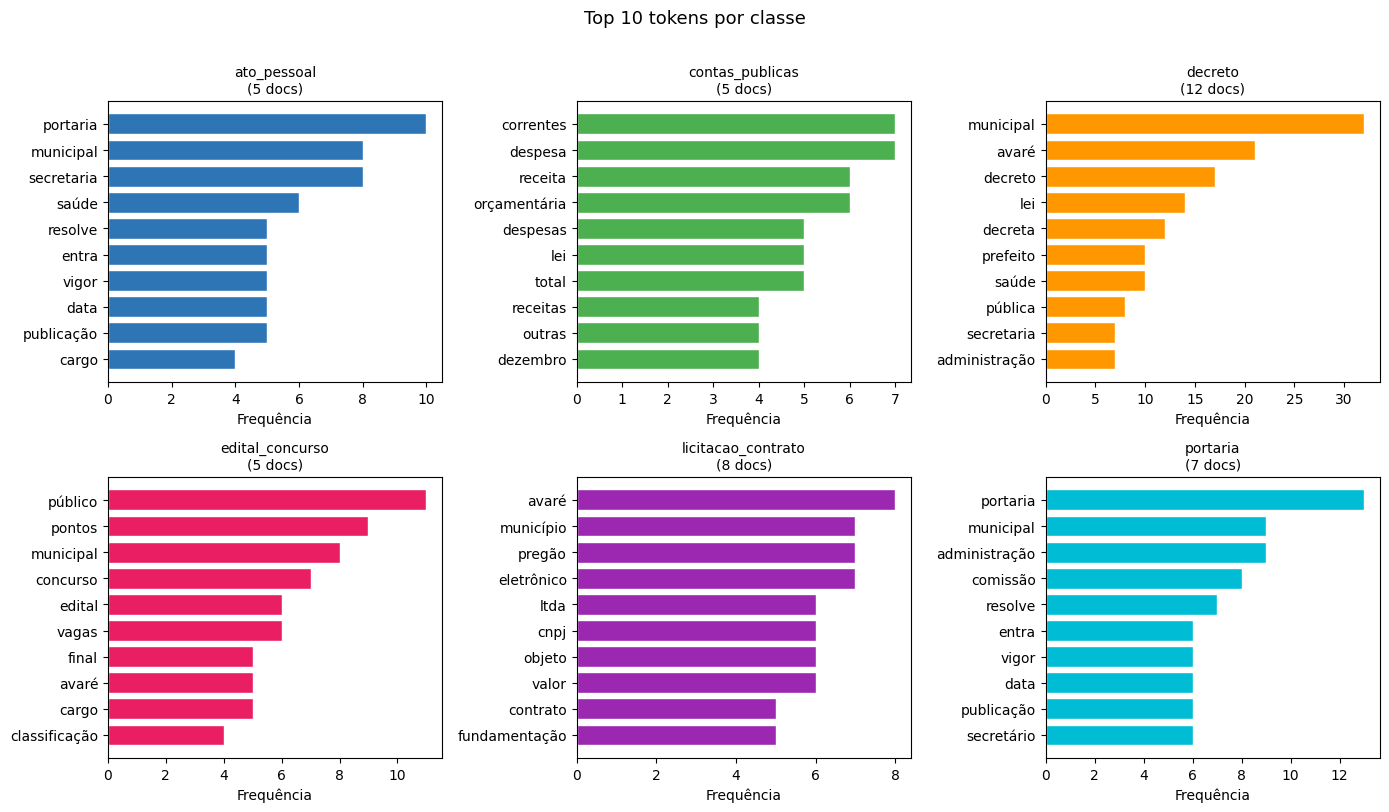

Gráfico salvo em docs/termos_por_classe.png


In [21]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, classe in enumerate(sorted(df['rotulo'].unique())):
    textos_classe = df[df['rotulo'] == classe]['texto']
    todas_palavras = []
    for t in textos_classe:
        todas_palavras.extend(tokenizar(t))
    
    top10 = Counter(todas_palavras).most_common(10)
    palavras, freqs = zip(*top10) if top10 else ([], [])
    
    axes[i].barh(list(palavras)[::-1], list(freqs)[::-1],
                 color=cores[i], edgecolor='white')
    axes[i].set_title(f'{classe}\n({len(textos_classe)} docs)', fontsize=10)
    axes[i].set_xlabel('Frequência')

plt.suptitle('Top 10 tokens por classe', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../docs/termos_por_classe.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo em docs/termos_por_classe.png')

**Interpretação:** Os termos discriminantes confirmam a coerência dos rótulos:
- `licitacao_contrato`: *pregão, eletrônico, cnpj, ltda, contrato, valor*
- `contas_publicas`: *receita, despesa, orçamentária, correntes, total*
- `edital_concurso`: *concurso, vagas, cargo, pontos, classificação*
- `decreto`: *decreta, prefeito, regulamenta, avaré*

Isso indica que o vocabulário tem poder discriminativo suficiente para o classificador.

---
## Atividade 2 — Tokenização

In [22]:
# Teste em 3 textos de classes diferentes
exemplos = [
    ('decreto',           'Decreto Municipal nº 8.742 - Fica decretado ponto facultativo pela Prefeitura.'),
    ('licitacao_contrato','Pregão Eletrônico 041/2025 - Aquisição de medicamentos, empresa vencedora Ltda CNPJ 12.345.'),
    ('edital_concurso',   'Edital de abertura Concurso Público 03/2025, vagas para Agente Administrativo, inscrições abertas.'),
]

for classe, texto in exemplos:
    tokens = tokenizar(texto)
    print(f'\n[{classe}]')
    print(f'  Entrada: {texto[:70]}...')
    print(f'  Tokens:  {tokens}')


[decreto]
  Entrada: Decreto Municipal nº 8.742 - Fica decretado ponto facultativo pela Pre...
  Tokens:  ['decreto', 'municipal', 'decretado', 'ponto', 'facultativo', 'prefeitura']

[licitacao_contrato]
  Entrada: Pregão Eletrônico 041/2025 - Aquisição de medicamentos, empresa venced...
  Tokens:  ['pregão', 'eletrônico', 'aquisição', 'medicamentos', 'empresa', 'vencedora', 'ltda', 'cnpj']

[edital_concurso]
  Entrada: Edital de abertura Concurso Público 03/2025, vagas para Agente Adminis...
  Tokens:  ['edital', 'abertura', 'concurso', 'público', 'vagas', 'agente', 'administrativo', 'inscrições', 'abertas']


---
## Atividade 3 — Vocabulário e Codificação

In [23]:
# Carrega vocabulário já gerado (apenas do treino — sem data leakage)
with open('../data/processed/vocab.json', encoding='utf-8') as f:
    vocab = json.load(f)

print(f'Tamanho do vocabulário: {len(vocab)} tokens')
print(f'Tokens especiais: <PAD>={vocab["<PAD>"]}, <UNK>={vocab["<UNK>"]}')
print(f'\nPrimeiros 10 tokens por frequência:')
print({k: v for k, v in list(vocab.items())[:12] if k not in ['<PAD>','<UNK>']})

Tamanho do vocabulário: 249 tokens
Tokens especiais: <PAD>=0, <UNK>=1

Primeiros 10 tokens por frequência:
{'municipal': 2, 'avaré': 3, 'lei': 4, 'portaria': 5, 'município': 6, 'administração': 7, 'saúde': 8, 'data': 9, 'secretaria': 10, 'entra': 11}


In [24]:
# Demonstração de codificação com padding
exemplo = 'Pregão eletrônico para registro de preços municipais'
ids = codificar_texto(exemplo, vocab, max_len=MAX_LEN)

print(f'Texto:      "{exemplo}"')
print(f'Tokens:     {tokenizar(exemplo)}')
print(f'IDs:        {ids}')
print(f'Comprimento: {len(ids)} (== MAX_LEN={MAX_LEN})')
print(f'Zeros (PAD): {ids.count(0)}')

Texto:      "Pregão eletrônico para registro de preços municipais"
Tokens:     ['pregão', 'eletrônico', 'registro', 'preços', 'municipais']
IDs:        [61, 62, 163, 106, 57, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Comprimento: 60 (== MAX_LEN=60)
Zeros (PAD): 55


---
## Atividade 4 — Codificação dos Rótulos

In [25]:
with open('../data/processed/label_map.json', encoding='utf-8') as f:
    label2id = json.load(f)

id2label = {v: k for k, v in label2id.items()}

print('label2id:', label2id)
print('\nExemplos de codificação:')
for rotulo in ['decreto', 'licitacao_contrato', 'edital_concurso']:
    print(f'  "{rotulo}" → {label2id[rotulo]}')

label2id: {'ato_pessoal': 0, 'contas_publicas': 1, 'decreto': 2, 'edital_concurso': 3, 'licitacao_contrato': 4, 'portaria': 5}

Exemplos de codificação:
  "decreto" → 2
  "licitacao_contrato" → 4
  "edital_concurso" → 3


---
## Atividade 5 — Dataset PyTorch

In [26]:
df['rotulo_id'] = df['rotulo'].map(label2id)

treino_df, teste_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['rotulo_id']
)
print(f'Treino: {len(treino_df)} | Teste: {len(teste_df)}')
print(f'\nDistribuição treino:')
print(treino_df['rotulo'].value_counts())

Treino: 33 | Teste: 9

Distribuição treino:
rotulo
decreto               9
licitacao_contrato    6
portaria              6
contas_publicas       4
edital_concurso       4
ato_pessoal           4
Name: count, dtype: int64


In [27]:
treino_ds = DiarioDataset(treino_df, vocab, label2id, max_len=MAX_LEN)
teste_ds  = DiarioDataset(teste_df,  vocab, label2id, max_len=MAX_LEN)

treino_loader = DataLoader(treino_ds, batch_size=8, shuffle=True)
teste_loader  = DataLoader(teste_ds,  batch_size=8, shuffle=False)

# Pega o primeiro lote e verifica formatos
x_lote, y_lote = next(iter(treino_loader))

print(f'Formato X: {x_lote.shape}  ← esperado: [batch_size, MAX_LEN] = [8, {MAX_LEN}]')
print(f'Formato y: {y_lote.shape}  ← esperado: [batch_size] = [8]')
print(f'Valores de X em [0, {len(vocab)-1}]: {x_lote.min().item()} a {x_lote.max().item()}')
print(f'Rótulos do lote: {[id2label[i.item()] for i in y_lote]}')
print('\n✅ Dataset funcionando corretamente!')

Formato X: torch.Size([8, 60])  ← esperado: [batch_size, MAX_LEN] = [8, 60]
Formato y: torch.Size([8])  ← esperado: [batch_size] = [8]
Valores de X em [0, 248]: 0 a 246
Rótulos do lote: ['decreto', 'licitacao_contrato', 'licitacao_contrato', 'contas_publicas', 'contas_publicas', 'portaria', 'edital_concurso', 'decreto']

✅ Dataset funcionando corretamente!


In [28]:
# Visualiza a sequência de um exemplo
x0, y0 = treino_ds[0]
tokens_decodificados = [k for k, v in vocab.items() if v in x0.tolist()]

print(f'Classe: {id2label[y0.item()]}')
print(f'Tensor X[0]: {x0.tolist()}')
print(f'Tokens PAD (0): {x0.tolist().count(0)} de {MAX_LEN}')

Classe: licitacao_contrato
Tensor X[0]: [88, 44, 44, 55, 6, 3, 56, 139, 29, 30, 45, 31, 46, 140, 30, 139, 1, 1, 141, 57, 24, 1, 142, 32, 33, 58, 89, 59, 1, 60, 47, 143, 61, 62, 9, 60, 63, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Tokens PAD (0): 23 de 60


---
## Atividade 6 — Comparação com PyTorch-NLP

In [29]:
# Instalação: pip install pytorch-nlp
try:
    from torchnlp.encoders.text import WhitespaceEncoder
    from torchnlp.encoders import LabelEncoder
    TORCHNLP = True
except ImportError:
    TORCHNLP = False
    print('pytorch-nlp não instalado. Execute: pip install pytorch-nlp')
    print('Mostrando comparação conceitual abaixo.')

pytorch-nlp não instalado. Execute: pip install pytorch-nlp
Mostrando comparação conceitual abaixo.


In [30]:
if TORCHNLP:
    # Encoder de texto — constrói vocabulário automaticamente
    textos_treino = treino_df['texto'].apply(
        lambda t: ' '.join(tokenizar(t))
    ).tolist()

    encoder_texto = WhitespaceEncoder(textos_treino)
    print(f'PyTorch-NLP vocab size: {encoder_texto.vocab_size}')
    print(f'Nossa implementação:    {len(vocab)}')

    exemplo = 'pregão eletrônico registro precos municipais'
    cod_lib  = encoder_texto.encode(exemplo)
    cod_manual = codificar_texto(exemplo, vocab, max_len=10)

    print(f'\nCodificação PyTorch-NLP: {cod_lib.tolist()}')
    print(f'Codificação manual:      {cod_manual}')

    # Encoder de rótulos
    encoder_rotulo = LabelEncoder(df['rotulo'].tolist())
    print(f'\nRótulo "decreto" → PyTorch-NLP: {encoder_rotulo.encode("decreto")}')
    print(f'Rótulo "decreto" → manual:       {label2id["decreto"]}')
else:
    print("""
COMPARAÇÃO CONCEITUAL (sem pytorch-nlp instalado):

| Aspecto              | Nossa implementação       | PyTorch-NLP              |
|----------------------|--------------------------|---------------------------|
| Vocabulário          | dict {token: int}         | objeto WhitespaceEncoder  |
| <PAD> / <UNK>        | explícito (0 e 1)         | automático                |
| Padding              | manual (lista + [0]*n)    | via encoder.encode()      |
| Encoder de rótulos   | dict label2id manual      | LabelEncoder automático   |
| Transparência        | total — vemos cada passo  | caixa cinza               |
| Flexibilidade        | alta — customizamos tudo  | limitado ao que a lib tem |
| Código para produção | mais verboso              | mais conciso              |

Conclusão: para fins didáticos, a implementação manual é superior — 
cada etapa é visível e compreensível. Para projetos em produção, 
PyTorch-NLP (ou HuggingFace Tokenizers) economiza tempo.
    """)


COMPARAÇÃO CONCEITUAL (sem pytorch-nlp instalado):

| Aspecto              | Nossa implementação       | PyTorch-NLP              |
|----------------------|--------------------------|---------------------------|
| Vocabulário          | dict {token: int}         | objeto WhitespaceEncoder  |
| <PAD> / <UNK>        | explícito (0 e 1)         | automático                |
| Padding              | manual (lista + [0]*n)    | via encoder.encode()      |
| Encoder de rótulos   | dict label2id manual      | LabelEncoder automático   |
| Transparência        | total — vemos cada passo  | caixa cinza               |
| Flexibilidade        | alta — customizamos tudo  | limitado ao que a lib tem |
| Código para produção | mais verboso              | mais conciso              |

Conclusão: para fins didáticos, a implementação manual é superior — 
cada etapa é visível e compreensível. Para projetos em produção, 
PyTorch-NLP (ou HuggingFace Tokenizers) economiza tempo.
    


---
## ✅ Conclusão da Etapa 3

| Entregável | Status |
|------------|--------|
| EDA com 3 gráficos | ✅ |
| `vocab.json` (248 tokens) | ✅ |
| `label_map.json` (6 classes) | ✅ |
| `src/dataset.py` — DiarioDataset | ✅ |
| DataLoader com tensores [8, 60] | ✅ |
| Comparação PyTorch-NLP | ✅ |

**Próximo passo — Etapa 4:** usar `treino_loader` e `teste_loader` para treinar e avaliar o classificador TextCNN / BiLSTM em `src/train.py`.